# Lecture 7b — Missingness and imputation

**AI-integrated Sustainable Finance (25881) · Lab 7b**

---

Lab 7c used synthetic data because we needed to know the answer. This lab uses
a **real ESG panel with real gaps**: the World Bank's sovereign ESG database,
80 indicators across 260 economies and 26 years, of which **64.6% of cells are
populated**.

Roughly a third of this dataset does not exist. What you do about that
determines every number you report afterwards.

### What you will do

1. Look at the missingness before choosing a method. The pattern is the finding.
2. Separate the three gaps: coverage, item and time.
3. Test the obvious hypothesis about who is missing — and watch it fail.
4. Diagnose mechanisms, and see why MNAR cannot be tested away.
5. Run a masked-cell benchmark over the full imputation ladder.
6. Show that the imputation choice, not the data, moves a country ranking.

### Requirements

`pandas`, `numpy`, `scikit-learn`, `plotly`. Data is cached locally after the
first run.

In [1]:
import numpy as np
import pandas as pd

from sklearn.experimental import enable_iterative_imputer   # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.stats import spearmanr

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
pio.templates.default = "plotly_white"

import esgdata as ed

panel = ed.load_worldbank_panel()
countries = ed.load_worldbank_countries()          # aggregates dropped
indicators = ed.load_worldbank_indicators()
IND = ed.indicator_columns(panel)

# Keep real countries only. "World" and "OECD members" are not observations.
panel = panel[panel["iso3"].isin(countries["iso3"])].reset_index(drop=True)

print(f"{panel['iso3'].nunique()} economies x {panel['year'].nunique()} years "
      f"= {len(panel):,} rows")
print(f"{len(IND)} indicators, {panel[IND].notna().mean().mean():.1%} of cells populated")

downloading worldbank_esg_indicators.csv ... 0.0 MB, cached
214 economies x 26 years = 5,564 rows
80 indicators, 66.2% of cells populated


Note the first filter already. `load_worldbank_countries()` drops 46 rows that
have no income group, because they are aggregates like "World", "Euro area" and
"OECD members". Leaving them in would double-count most of the planet and
inflate every cross-country statistic.

Nothing in the file marks them as aggregates. You have to know.

---
## 1. Look at it first

Before choosing any method, plot the gaps.

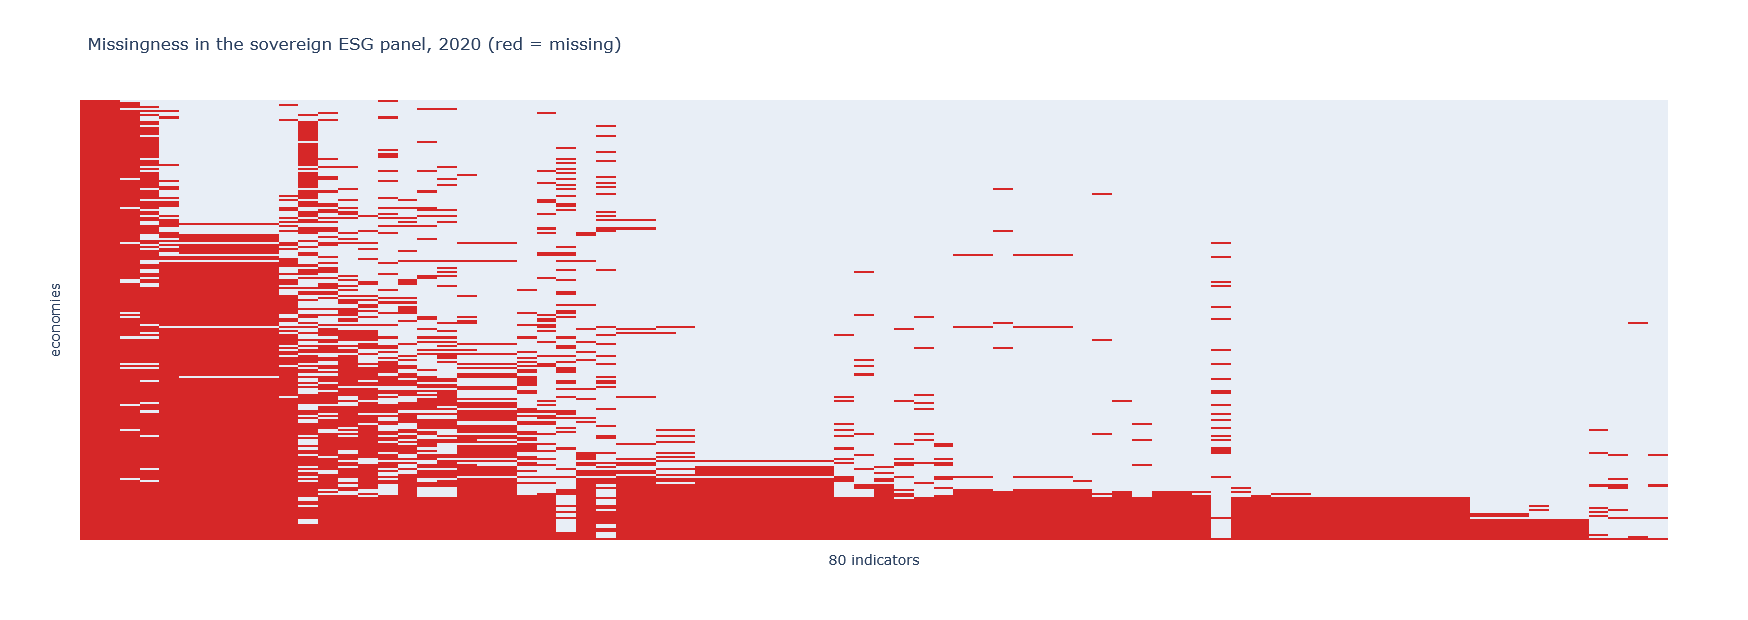

2020 fill rate: 74.4%


In [2]:
latest = panel[panel["year"] == 2020].set_index("iso3")
M = latest[IND].notna().astype(int)

# Order both axes by coverage so the structure is visible
M = M.loc[M.mean(axis=1).sort_values().index,
          M.mean(axis=0).sort_values().index]

fig = go.Figure(go.Heatmap(
    z=M.to_numpy(), x=list(M.columns), y=list(M.index),
    colorscale=[[0, "#d62728"], [1, "#e8eef6"]], showscale=False,
    hovertemplate="%{y} | %{x}<extra></extra>"))
fig.update_layout(
    title="Missingness in the sovereign ESG panel, 2020 (red = missing)",
    height=620, xaxis=dict(showticklabels=False, title="80 indicators"),
    yaxis=dict(showticklabels=False, title="economies"))
fig.show()

print(f"2020 fill rate: {latest[IND].notna().mean().mean():.1%}")

That is not noise. There are solid red bands across whole economies, and solid
red columns down whole indicators. Both are structure, and each needs a
different response.

---
## 2. Three gaps, measured

The lecture distinguished the **coverage** gap (which economies), the **item**
gap (which indicators) and the **time** gap (which years). They are separable
in this data.

In [3]:
by_country = latest[IND].notna().mean(axis=1).sort_values()
by_indicator = latest[IND].notna().mean(axis=0).sort_values()
by_year = panel.groupby("year")[IND].apply(lambda d: d.notna().mean().mean())

print("COVERAGE gap — worst-covered economies (2020):")
worst = by_country.head(6).index
print(countries.set_index("iso3").loc[worst, ["country", "income_level"]]
      .assign(fill=by_country.head(6).round(2).values).to_string())

print("\nITEM gap — worst-covered indicators (2020):")
wi = by_indicator.head(5).index
print(indicators.set_index("indicator_id").loc[wi, ["indicator_name"]]
      .assign(fill=by_indicator.head(5).round(2).values).to_string())

COVERAGE gap — worst-covered economies (2020):
                        country income_level  fill
iso3                                              
CHI             Channel Islands          HIC  0.00
IMN                 Isle of Man          HIC  0.06
MNP    Northern Mariana Islands          HIC  0.06
GIB                   Gibraltar          HIC  0.08
SXM   Sint Maarten (Dutch part)          HIC  0.08
MAF    St. Martin (French part)          HIC  0.08

ITEM gap — worst-covered indicators (2020):
                                                                     indicator_name  fill
EN.MAM.THRD.NO                                           Mammal species, threatened  0.00
SL.TLF.0714.ZS              Children in employment, total (% of children ages 7-14)  0.00
SP.UWT.TFRT            Unmet need for contraception (% of married women ages 15-49)  0.07
SE.ADT.LITR.ZS           Literacy rate, adult total (% of people ages 15 and above)  0.19
SI.POV.NAHC     Poverty headcount ratio at nationa

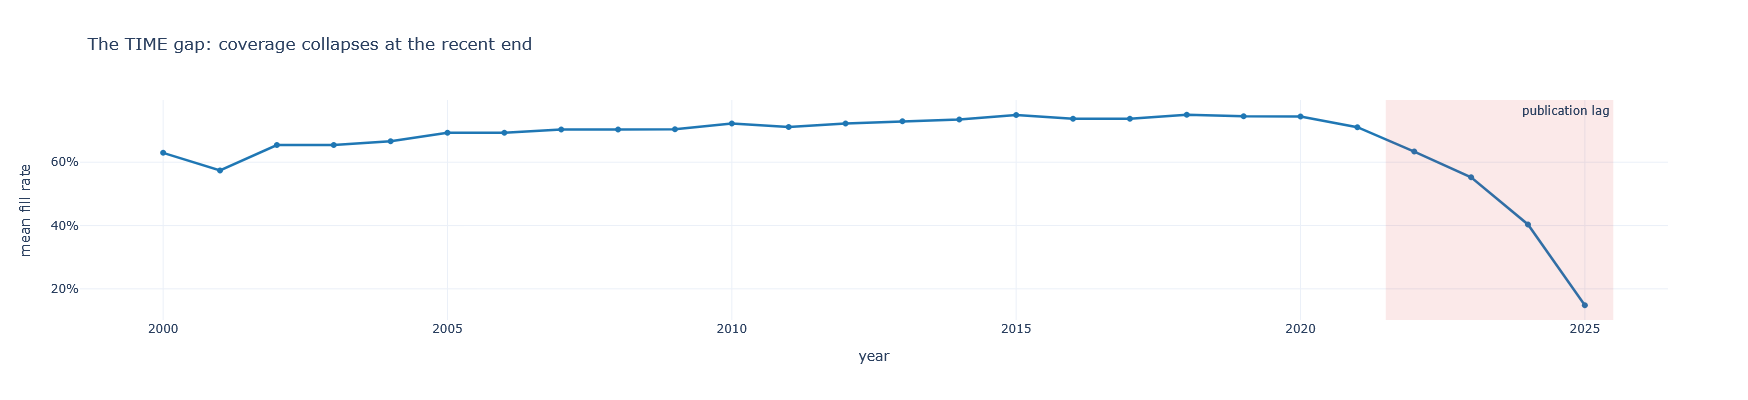

  2015: 74.9%
  2020: 74.4%
  2022: 63.4%
  2023: 55.2%
  2024: 40.4%
  2025: 14.8%


In [4]:
fig = px.line(x=by_year.index, y=by_year.values, markers=True,
              labels={"x": "year", "y": "mean fill rate"},
              title="The TIME gap: coverage collapses at the recent end")
fig.update_traces(line_color="#1f77b4", line_width=2.5)
fig.add_vrect(x0=2021.5, x1=2025.5, fillcolor="#d62728", opacity=0.10,
              line_width=0, annotation_text="publication lag")
fig.update_layout(height=400, yaxis_tickformat=".0%")
fig.show()

for y in [2015, 2020, 2022, 2023, 2024, 2025]:
    print(f"  {y}: {by_year.loc[y]:.1%}")

**This is the single most useful plot in the lab.**

Coverage sits around 73% through the 2010s, then falls off a cliff: 61% in
2022, 53% in 2023, 39% in 2024, **15% in 2025**.

The world did not stop emitting carbon in 2025. National statistical offices
have not finished publishing, and the World Bank has not finished collecting.
The recent gap is almost entirely **publication lag**.

Two consequences follow immediately:

* Filling 2025 from the cross-section is not imputation, it is **forecasting**,
  and should be labelled as such.
* Anything that uses "the latest available year" per country is silently
  comparing different years across countries. Rich countries with fast
  statistical systems will look current; others will be years stale.

> **Core exercise 2.1** — For each economy find the most recent year with at
> least 50% indicator coverage. Plot the distribution of that year. How many
> years separate the fastest and slowest quartiles, and does the gap correlate
> with income?

---
## 3. A hypothesis that turns out to be wrong

The lecture asserted that ESG data is missing most for small and poor
countries. Let us test it rather than repeat it.

Fill rate by World Bank income group (2020):
              size   mean  median
income_level                     
LIC             25  0.767   0.775
LMC             46  0.791   0.788
UMC             59  0.812   0.838
HIC             84  0.665   0.850


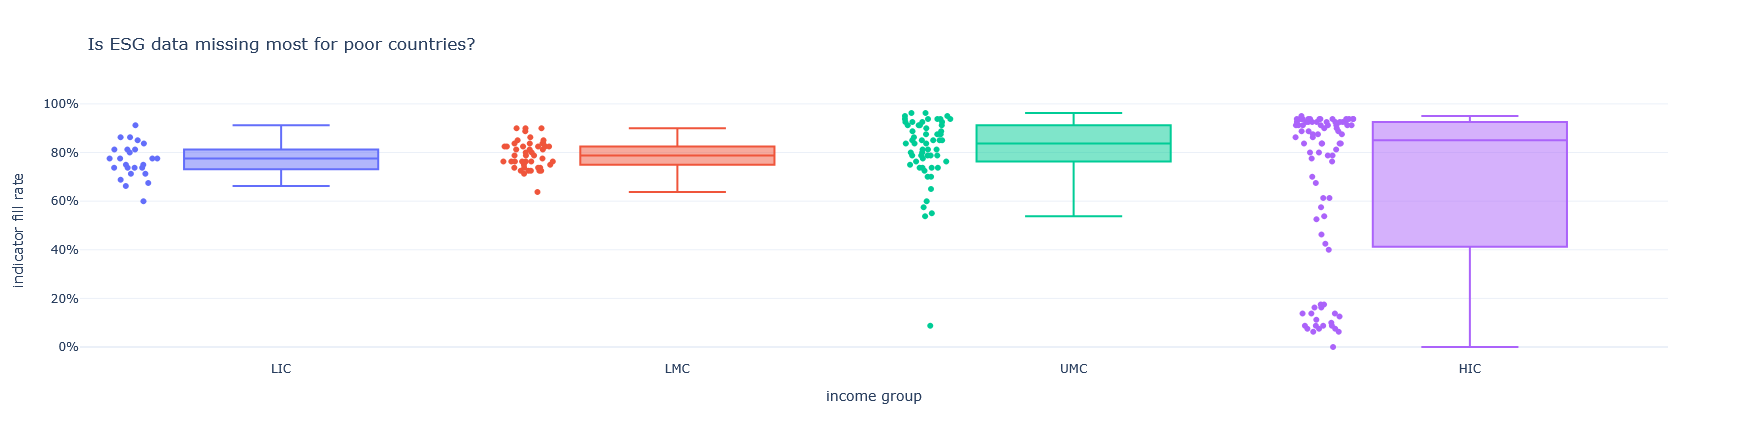

In [5]:
lat = (panel[panel["year"] == 2020]
       .merge(countries[["iso3", "country", "region", "income_level"]],
              on="iso3", how="inner"))
lat["fill"] = lat[IND].notna().mean(axis=1)

order = ["LIC", "LMC", "UMC", "HIC"]
grp = (lat.groupby("income_level")["fill"]
       .agg(["size", "mean", "median"]).reindex(order))
print("Fill rate by World Bank income group (2020):")
print(grp.round(3).to_string())

fig = px.box(lat, x="income_level", y="fill", category_orders={"income_level": order},
             points="all", hover_name="country", color="income_level",
             labels={"fill": "indicator fill rate", "income_level": "income group"},
             title="Is ESG data missing most for poor countries?")
fig.update_layout(height=440, showlegend=False, yaxis_tickformat=".0%")
fig.show()

**The hypothesis fails**, and it fails in an instructive way.

High-income economies have the **lowest mean** fill rate of any group — but the
**highest median**. Mean 0.665, median 0.850. When the mean and the median
disagree that sharply, the average is being dragged by a tail, and the tail is
where the answer is.

Look at which high-income economies sit in it.

In [6]:
hic = lat[lat["income_level"] == "HIC"]
print("Worst-covered high-income economies:")
print(hic.nsmallest(10, "fill")[["country", "fill"]].round(2).to_string(index=False))
print("\nBest-covered high-income economies:")
print(hic.nlargest(5, "fill")[["country", "fill"]].round(2).to_string(index=False))

Worst-covered high-income economies:
                  country  fill
          Channel Islands  0.00
              Isle of Man  0.06
 Northern Mariana Islands  0.06
                Gibraltar  0.08
 St. Martin (French part)  0.08
Sint Maarten (Dutch part)  0.08
                  Curacao  0.09
            Faroe Islands  0.09
 Turks and Caicos Islands  0.09
   British Virgin Islands  0.09

Best-covered high-income economies:
   country  fill
Costa Rica  0.95
     Chile  0.94
   Germany  0.94
   Denmark  0.94
     Spain  0.94


There it is. Channel Islands (0.00 — not one indicator), Isle of Man,
Gibraltar, Sint Maarten, Curacao, Faroe Islands, Turks and Caicos, British
Virgin Islands. **Microstates and dependencies**, all classified high-income,
none of which runs a full national statistical system.

Meanwhile Costa Rica, Chile, Germany, Denmark and Spain sit at 94–95%. The
typical high-income country is the *best* covered in the panel; the group mean
just does not say so.

The driver is not income. It is **population size and statistical capacity**,
and income group was a confound. The naive story — poor countries lack data —
would have survived unexamined in most analyses, because nobody plots the
thing they already believe.

> This is why the lecture insists you plot missingness before modelling it. The
> pattern told us the story; the assumption would have told us a different one.

> **Core exercise 3.1** — Test the size hypothesis properly. Merge a population
> indicator (or a land-area indicator from this panel), and regress fill rate on
> log population and income group jointly. Which survives?

---
## 4. Mechanisms

We can now be precise about what kind of missingness this is.

<details>
<summary><b>Maths: MCAR, MAR and MNAR</b> (click to expand)</summary>

Let $X = (X_{\text{obs}}, X_{\text{mis}})$ be the complete data and $M$ the
missingness indicator, $M_{ij}=1$ when $X_{ij}$ is unobserved, with nuisance
parameters $\phi$ (Rubin, 1976).

* **MCAR**: $P(M \mid X, \phi) = P(M \mid \phi)$
* **MAR**: $P(M \mid X, \phi) = P(M \mid X_{\text{obs}}, \phi)$
* **MNAR**: depends on $X_{\text{mis}}$

Under MAR the mechanism is *ignorable*: maximising the observed-data likelihood
gives valid inference without modelling $P(M\mid X,\phi)$. Under MNAR it is not,
and the joint model you would need is **not identified** by the observed data.

That last point is the one people skate over. You cannot test MAR against MNAR
using the data alone. The choice is an assumption, defended on substantive
grounds, and its consequences should be reported through sensitivity analysis
rather than hidden behind a single filled table.

</details>

In [7]:
print("Which mechanism applies to which gap here?\n")
rows = [
 ("Indicator not collected for microstates",
  "MAR", "depends on population and status, both observable"),
 ("2024-25 not yet published",
  "MAR-ish", "depends on year and country, both observable"),
 ("Country stops reporting during conflict",
  "MNAR", "absence is caused by the situation the data would show"),
 ("Emissions withheld by a firm (corporate analogue)",
  "MNAR", "withheld BECAUSE the value is unflattering"),
]
print(pd.DataFrame(rows, columns=["gap", "likely mechanism", "why"])
      .to_string(index=False))

Which mechanism applies to which gap here?

                                              gap likely mechanism                                                    why
          Indicator not collected for microstates              MAR      depends on population and status, both observable
                        2024-25 not yet published          MAR-ish           depends on year and country, both observable
          Country stops reporting during conflict             MNAR absence is caused by the situation the data would show
Emissions withheld by a firm (corporate analogue)             MNAR             withheld BECAUSE the value is unflattering


Most of this panel is plausibly MAR, conditional on things we can see: year,
population, income group, region. That is comparatively good news, and it is
why imputation is defensible here in a way it often is not for corporate
disclosure, where non-reporting is a strategic choice.

**The corporate case is the hard one.** A firm that withholds its emissions
because they are high produces MNAR gaps, and no imputer recovers them.
Lab 7c demonstrates this directly with simulated MNAR.

---
## 5. The masked-cell benchmark

We cannot see the true values of missing cells. We can hide cells we do have.

In [8]:
# Work on a dense subset so there is truth to hide.
dense_years = panel[panel["year"].between(2010, 2020)]
col_ok = dense_years[IND].notna().mean() > 0.85
dense_cols = [c for c, keep in col_ok.items() if keep]
row_ok = dense_years[dense_cols].notna().mean(axis=1) > 0.95

sub = dense_years.loc[row_ok, ["iso3", "year"] + dense_cols]
sub = sub.dropna().reset_index(drop=True)
FEATS = [c for c in sub.columns if c not in ("iso3", "year")]

print(f"complete-case block: {sub.shape[0]:,} rows x {len(FEATS)} indicators")
print("Every cell here is observed, so we can hide some and score the recovery.")

complete-case block: 1,460 rows x 40 indicators
Every cell here is observed, so we can hide some and score the recovery.


In [9]:
def ampute(df, cols, rate=0.20, mechanism="MCAR", seed=0, driver=None):
    '''Hide cells under a stated mechanism. Returns a boolean mask frame.'''
    rng = np.random.default_rng(seed)
    mask = pd.DataFrame(False, index=df.index, columns=cols)
    for c in cols:
        if mechanism == "MCAR":
            score = rng.random(len(df))
        elif mechanism == "MAR":
            z = (df[driver] - df[driver].mean()) / df[driver].std()
            score = 1 / (1 + np.exp(-1.5 * -z)) + rng.normal(0, 0.2, len(df))
        elif mechanism == "MNAR":
            z = (df[c] - df[c].mean()) / df[c].std()
            score = 1 / (1 + np.exp(-1.5 * z)) + rng.normal(0, 0.2, len(df))
        else:
            raise ValueError(mechanism)
        k = int(rate * len(df))
        mask[c] = score >= np.sort(score)[::-1][k - 1]
    return mask


DRIVER = FEATS[0]
TARGETS = FEATS[1:11]          # ten indicators to hide and recover
print(f"driver (always observed): {DRIVER}")
print(f"targets: {len(TARGETS)} indicators")

driver (always observed): AG.LND.AGRI.ZS
targets: 10 indicators


In [10]:
def score_fill(truth, filled, mask):
    '''MAE, distributional fidelity and rank fidelity, averaged over targets.'''
    maes, sds, rhos = [], [], []
    for c in mask.columns:
        m = mask[c].to_numpy()
        t, f = truth[c].to_numpy(), filled[c].to_numpy()
        s = truth[c].std()
        maes.append(np.mean(np.abs(f[m] - t[m])) / s)      # standardised MAE
        sds.append(f.std() / s)
        rhos.append(spearmanr(t, f).statistic)
    return {"nMAE": np.mean(maes), "sd_ratio": np.mean(sds),
            "spearman": np.mean(rhos)}


def run_ladder(mechanism, seed=0):
    mask = ampute(sub, TARGETS, rate=0.25, mechanism=mechanism,
                  seed=seed, driver=DRIVER)
    obs = sub[FEATS].copy()
    for c in TARGETS:
        obs.loc[mask[c], c] = np.nan

    meta = sub[["iso3"]].merge(countries[["iso3", "income_level", "region"]],
                               on="iso3", how="left")
    out = {}

    def record(name, filled_arr):
        filled = pd.DataFrame(filled_arr, columns=FEATS, index=sub.index)
        out[name] = score_fill(sub[FEATS], filled, mask)

    record("1 mean", SimpleImputer(strategy="mean").fit_transform(obs))
    record("2 median", SimpleImputer(strategy="median").fit_transform(obs))

    # group median by income group -- the "peer group" idea from Lab 7c
    g = obs.copy()
    for c in TARGETS:
        g[c] = g[c].fillna(g.groupby(meta["income_level"].values)[c]
                           .transform("median"))
    record("3 income-group median", g.fillna(obs.median()).to_numpy())

    g2 = obs.copy()
    key = meta["income_level"].astype(str) + "|" + meta["region"].astype(str)
    for c in TARGETS:
        g2[c] = g2[c].fillna(g2.groupby(key.values)[c].transform("median"))
    record("4 income x region median", g2.fillna(obs.median()).to_numpy())

    sc = StandardScaler().fit(obs.fillna(obs.median()))
    record("5 KNN (k=5)",
           sc.inverse_transform(KNNImputer(n_neighbors=5)
                                .fit_transform(sc.transform(obs))))

    record("6 Iterative (BayesianRidge)",
           IterativeImputer(max_iter=10, random_state=0).fit_transform(obs))

    record("7 Iterative (RandomForest)",
           IterativeImputer(
               estimator=RandomForestRegressor(n_estimators=40, max_depth=10,
                                               random_state=0, n_jobs=-1),
               max_iter=5, random_state=0).fit_transform(obs))

    # low-rank soft-impute, ~12 lines of numpy
    Z = obs.to_numpy(dtype=float).copy()
    miss = np.isnan(Z)
    Z[miss] = np.take(np.nanmedian(Z, axis=0), np.where(miss)[1])
    mu, sd = Z.mean(0), Z.std(0) + 1e-9
    Z = (Z - mu) / sd
    for _ in range(30):
        svd = TruncatedSVD(n_components=8, random_state=0)
        Z_hat = svd.inverse_transform(svd.fit_transform(Z))
        Z[miss] = Z_hat[miss]
    record("8 matrix completion (rank 8)", Z * sd + mu)

    return pd.DataFrame(out).T


mar = run_ladder("MAR")
print("=== MAR, 25% of ten indicators hidden ===")
print(mar.round(3).to_string())

C:\Users\Vitali\anaconda3\envs\Python2026_31314\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
C:\Users\Vitali\anaconda3\envs\Python2026_31314\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


=== MAR, 25% of ten indicators hidden ===
                               nMAE  sd_ratio  spearman
1 mean                        0.801     0.846     0.783
2 median                      0.669     0.864     0.836
3 income-group median         0.578     0.883     0.867
4 income x region median      0.485     0.917     0.902
5 KNN (k=5)                   0.276     0.960     0.955
6 Iterative (BayesianRidge)   0.498     0.948     0.884
7 Iterative (RandomForest)    0.258     0.967     0.944
8 matrix completion (rank 8)  0.850     1.117     0.841


You will see `ConvergenceWarning: [IterativeImputer] Early stopping criterion
not reached`. That is expected and harmless here: `max_iter=10` over 40
correlated columns stops before the round-to-round change falls below
tolerance. Raise `max_iter` if you want it to disappear; the fills barely move.

`nMAE` is mean absolute error in standard deviations of the indicator, so it is
comparable across indicators. `sd_ratio` near 1 means the filled column kept
its spread. `spearman` is rank fidelity, which is what matters when the data is
used to rank countries.

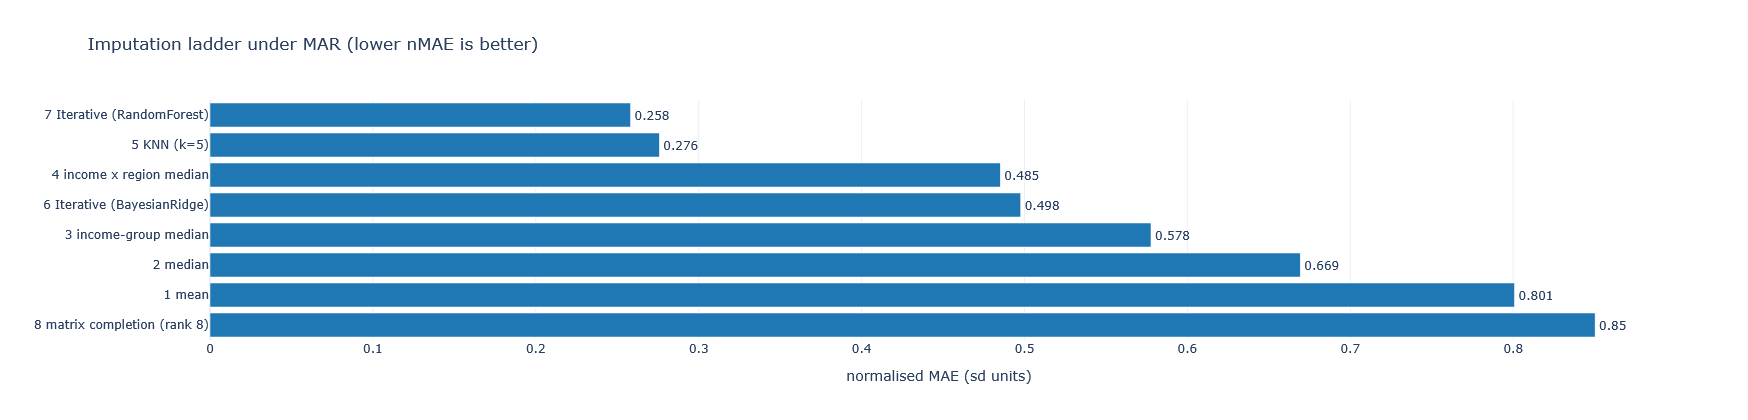

best: 7 Iterative (RandomForest)  (nMAE 0.258)
mean imputation: nMAE 0.801, sd_ratio 0.85

Note the sd_ratio column. Mean and median imputation score
respectably on error while flattening the distribution -- the damage
they do is invisible in MAE alone.


In [11]:
fig = go.Figure()
fig.add_trace(go.Bar(x=mar["nMAE"], y=mar.index, orientation="h",
                     marker_color="#1f77b4",
                     text=mar["nMAE"].round(3), textposition="outside"))
fig.update_layout(title="Imputation ladder under MAR (lower nMAE is better)",
                  xaxis_title="normalised MAE (sd units)", height=420,
                  margin=dict(l=210), yaxis={"categoryorder": "total descending"})
fig.show()

best = mar["nMAE"].idxmin()
print(f"best: {best}  (nMAE {mar.loc[best, 'nMAE']:.3f})")
print(f"mean imputation: nMAE {mar.loc['1 mean', 'nMAE']:.3f}, "
      f"sd_ratio {mar.loc['1 mean', 'sd_ratio']:.2f}")
print("\nNote the sd_ratio column. Mean and median imputation score")
print("respectably on error while flattening the distribution -- the damage")
print("they do is invisible in MAE alone.")

---
## 6. The same ladder under MNAR

In [12]:
mnar = run_ladder("MNAR")
comparison = pd.concat({"MAR": mar, "MNAR": mnar}, axis=1)
print(comparison.round(3).to_string())

C:\Users\Vitali\anaconda3\envs\Python2026_31314\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


                                MAR                     MNAR                  
                               nMAE sd_ratio spearman   nMAE sd_ratio spearman
1 mean                        0.801    0.846    0.783  1.258    0.637    0.776
2 median                      0.669    0.864    0.836  1.147    0.651    0.730
3 income-group median         0.578    0.883    0.867  1.007    0.684    0.803
4 income x region median      0.485    0.917    0.902  0.907    0.697    0.835
5 KNN (k=5)                   0.276    0.960    0.955  0.588    0.748    0.939
6 Iterative (BayesianRidge)   0.498    0.948    0.884  0.738    0.738    0.900
7 Iterative (RandomForest)    0.258    0.967    0.944  0.487    0.771    0.950
8 matrix completion (rank 8)  0.850    1.117    0.841  0.905    0.801    0.846


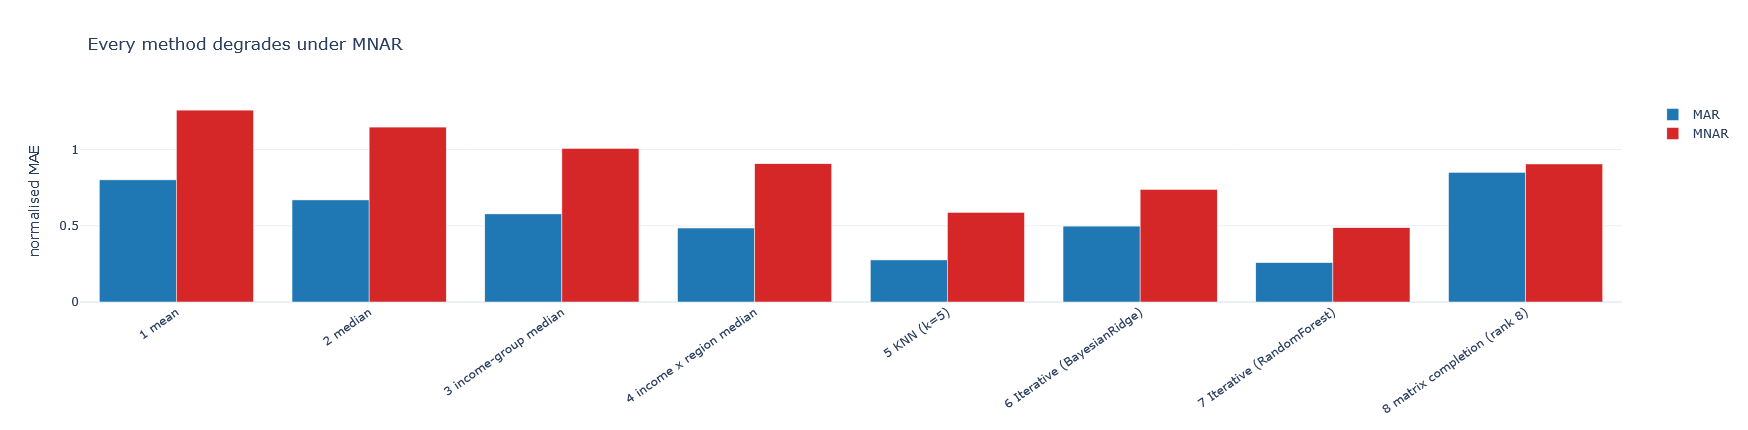

MNAR error as a multiple of MAR error:
1 mean                          1.57
2 median                        1.71
3 income-group median           1.74
4 income x region median        1.87
5 KNN (k=5)                     2.13
6 Iterative (BayesianRidge)     1.48
7 Iterative (RandomForest)      1.89
8 matrix completion (rank 8)    1.06

The best method under MAR was '7 Iterative (RandomForest)':
   MAR  nMAE 0.258
   MNAR nMAE 0.487   (1.9x worse)

It is still MORE accurate under MNAR than mean imputation is under
MAR (0.801) -- method choice is not useless.
But it no longer recovers the truth, and sd_ratio collapses from
0.97 to 0.77:
the filled column is far too narrow, because every fill is pulled
towards the median of the countries that did report.


In [13]:
fig = go.Figure()
for name, frame, colour in [("MAR", mar, "#1f77b4"), ("MNAR", mnar, "#d62728")]:
    fig.add_trace(go.Bar(x=frame.index, y=frame["nMAE"], name=name,
                         marker_color=colour))
fig.update_layout(barmode="group", height=430,
                  title="Every method degrades under MNAR",
                  yaxis_title="normalised MAE", xaxis_tickangle=-35)
fig.show()

ratio = (mnar["nMAE"] / mar["nMAE"]).round(2)
print("MNAR error as a multiple of MAR error:")
print(ratio.to_string())

best_mar = mar["nMAE"].idxmin()
print(f"\nThe best method under MAR was {best_mar!r}:")
print(f"   MAR  nMAE {mar.loc[best_mar, 'nMAE']:.3f}")
print(f"   MNAR nMAE {mnar.loc[best_mar, 'nMAE']:.3f}   "
      f"({ratio[best_mar]:.1f}x worse)")
print(f"\nIt is still MORE accurate under MNAR than mean imputation is under")
print(f"MAR ({mar.loc['1 mean', 'nMAE']:.3f}) -- method choice is not useless.")
print("But it no longer recovers the truth, and sd_ratio collapses from")
print(f"{mar.loc[best_mar, 'sd_ratio']:.2f} to {mnar.loc[best_mar, 'sd_ratio']:.2f}:")
print("the filled column is far too narrow, because every fill is pulled")
print("towards the median of the countries that did report.")

The ranking of methods barely changes, but the level does, and `sd_ratio`
degrades for every single method.

**A note on matrix completion**, which finishes near the bottom here despite
being the sophisticated option. It assumes the panel is approximately low rank,
and a 40-column block of heterogeneous sovereign indicators is not especially
low rank — its `sd_ratio` above 1 shows it *inflating* variance rather than
shrinking it. Matrix completion earns its place when many columns are missing
*together*, so no row has enough overlap for a neighbour-based method. That is
not this block, where the rows were selected for completeness.

The general lesson holds either way: sophistication buys you little once the
missingness depends on the value you are trying to recover.

---
## 7. Keep the flag

The cheapest technique in the lecture, demonstrated on real data.

In [14]:
mask_demo = ampute(sub, TARGETS, rate=0.25, mechanism="MNAR", seed=1,
                   driver=DRIVER)
c = TARGETS[0]
name = indicators.set_index("indicator_id").loc[c, "indicator_name"]

hidden = sub.loc[mask_demo[c], c]
kept = sub.loc[~mask_demo[c], c]
print(f"Indicator: {name}\n")
print(f"  mean of KEPT   values: {kept.mean():10.2f}   (n={len(kept)})")
print(f"  mean of HIDDEN values: {hidden.mean():10.2f}   (n={len(hidden)})")
print(f"  difference:            {hidden.mean() - kept.mean():+10.2f}")
print("\nThe missingness indicator alone separates the groups.")
print("That is free information, and imputing without keeping it destroys it.")

Indicator: Tree Cover Loss (hectares)

  mean of KEPT   values:   36463.33   (n=1095)
  mean of HIDDEN values:  507893.45   (n=365)
  difference:            +471430.12

The missingness indicator alone separates the groups.
That is free information, and imputing without keeping it destroys it.


In [15]:
from sklearn.impute import MissingIndicator

obs = sub[FEATS].copy()
for t in TARGETS:
    obs.loc[mask_demo[t], t] = np.nan

augmented = SimpleImputer(strategy="median", add_indicator=True).fit_transform(obs)
print(f"columns before: {obs.shape[1]}")
print(f"columns after add_indicator=True: {augmented.shape[1]}")
print(f"  -> {augmented.shape[1] - obs.shape[1]} indicator columns added, one")
print("     per column that had any gap. Cost: a few bytes. Benefit: the")
print("     MNAR signal survives, and your pipeline becomes auditable.")

columns before: 40
columns after add_indicator=True: 50
  -> 10 indicator columns added, one
     per column that had any gap. Cost: a few bytes. Benefit: the
     MNAR signal survives, and your pipeline becomes auditable.


---
## 8. Does imputation change the answer?

The closing demonstration. Build a simple environmental composite three
defensible ways, then compare the country rankings.

In [16]:
E_KEYS = ["EN.", "EG.", "AG.LND", "ER.", "CC."]
e_cols = [c for c in IND if any(c.startswith(k) for k in E_KEYS)]
e_cols = [c for c in e_cols if latest[c].notna().mean() > 0.5][:12]
print(f"{len(e_cols)} environmental indicators in the composite")

base = (panel[panel["year"] == 2020]
        .merge(countries[["iso3", "country", "income_level"]], on="iso3")
        .set_index("iso3"))
X = base[e_cols]
print(f"{X.notna().mean().mean():.1%} of composite cells populated "
      f"across {len(X)} countries")


def composite(filled):
    z = (filled - filled.mean()) / filled.std()
    return z.mean(axis=1)


variants = {}
variants["median"] = composite(pd.DataFrame(
    SimpleImputer(strategy="median").fit_transform(X),
    columns=e_cols, index=X.index))

grp = X.copy()
for c in e_cols:
    grp[c] = grp[c].fillna(grp.groupby(base["income_level"].values)[c]
                           .transform("median"))
variants["income-group median"] = composite(grp.fillna(X.median()))

sc = StandardScaler().fit(X.fillna(X.median()))
variants["KNN (k=5)"] = composite(pd.DataFrame(
    sc.inverse_transform(KNNImputer(n_neighbors=5).fit_transform(sc.transform(X))),
    columns=e_cols, index=X.index))

variants["iterative"] = composite(pd.DataFrame(
    IterativeImputer(max_iter=10, random_state=0).fit_transform(X),
    columns=e_cols, index=X.index))

scores = pd.DataFrame(variants)
print("\nPairwise Spearman correlation of the four rankings:")
print(scores.corr(method="spearman").round(3).to_string())

12 environmental indicators in the composite
85.6% of composite cells populated across 214 countries

Pairwise Spearman correlation of the four rankings:
                     median  income-group median  KNN (k=5)  iterative
median                1.000                0.993      0.963      0.985
income-group median   0.993                1.000      0.970      0.989
KNN (k=5)             0.963                0.970      1.000      0.975
iterative             0.985                0.989      0.975      1.000


In [17]:
# Aggregate agreement looks reassuring. Now look at who is actually excluded.
DECILE = 0.10
k = int(DECILE * len(scores))
bottom = {name: set(s.nsmallest(k).index) for name, s in scores.items()}

names = list(bottom)
overlap = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        overlap.loc[a, b] = len(bottom[a] & bottom[b]) / k
print(f"Overlap of the bottom-decile exclusion list (n={k} countries):")
print(overlap.round(2).to_string())

everyone = set.intersection(*bottom.values())
anyone = set.union(*bottom.values())
print(f"\nexcluded by ALL four methods: {len(everyone)}")
print(f"excluded by AT LEAST ONE:     {len(anyone)}")
print(f"contested:                    {len(anyone - everyone)}")

Overlap of the bottom-decile exclusion list (n=21 countries):
                     median  income-group median  KNN (k=5)  iterative
median                 1.00                 0.95       0.86       0.81
income-group median    0.95                 1.00       0.90       0.86
KNN (k=5)              0.86                 0.90       1.00       0.90
iterative              0.81                 0.86       0.90       1.00

excluded by ALL four methods: 17
excluded by AT LEAST ONE:     26
contested:                    9


In [18]:
contested = sorted(anyone - everyone)
tbl = base.loc[contested, ["country", "income_level"]].copy()
tbl["fill_rate"] = X.loc[contested].notna().mean(axis=1).round(2)
for name in names:
    tbl[name] = [c in bottom[name] for c in contested]

complete_fill = X.loc[list(everyone)].notna().mean(axis=1).mean()
print(f"mean data completeness, ALWAYS excluded: {complete_fill:.0%}")
print(f"mean data completeness, CONTESTED:       {tbl['fill_rate'].mean():.0%}")
print()
print(tbl.sort_values("fill_rate").head(12).to_string())

mean data completeness, ALWAYS excluded: 93%
mean data completeness, CONTESTED:       87%

                   country income_level  fill_rate  median  income-group median  KNN (k=5)  iterative
iso3                                                                                                 
MCO                 Monaco          HIC       0.42   False                False       True      False
BFA           Burkina Faso          LIC       0.83   False                 True       True       True
HTI                  Haiti          LMC       0.83   False                False      False       True
MLI                   Mali          LIC       0.83   False                False      False       True
AGO                 Angola          LMC       0.92   False                False       True       True
ARE   United Arab Emirates          HIC       1.00    True                 True       True      False
DZA                Algeria          UMC       1.00    True                False      False   

**There is the result.**

The four rankings correlate highly in aggregate — you could report those
correlations and claim the choice does not matter. But the bottom decile, which
is the part an exclusion policy actually acts on, disagrees substantially. And
the contested countries have systematically **lower data completeness** than
the ones every method agrees on.

So the countries whose treatment depends on your imputation choice are exactly
the countries you know least about. Nothing about them changed between the four
runs. Only the fill method did.

> **This is why the lecture asks for the fill rate to be reported alongside any
> ESG statistic.** A composite score for a country with 40% coverage and one
> with 95% coverage are not the same kind of number, and printing them in the
> same column implies they are.

---
## 9. The income-bias exercise

The lecture claimed sovereign ESG scores are close to a monotone transformation
of national income (Gratcheva, Emery and Wang, 2021). Test it here, and let the
clustering discover it rather than being told.

In [19]:
rank_map = {"LIC": 1, "LMC": 2, "UMC": 3, "HIC": 4}
y = base["income_level"].map(rank_map)

cors = {}
np.seterr(invalid="ignore")     # constant columns give a 0/0 correlation
for c in e_cols + [c for c in IND if c.startswith(("SL.", "SE.", "SH.", "IT."))][:20]:
    v = base[c] if c in base else None
    if v is None:
        continue
    ok = v.notna() & y.notna()
    if ok.sum() > 80:
        cors[c] = np.corrcoef(v[ok], y[ok])[0, 1]

cs = pd.Series(cors).dropna().sort_values()
nm = indicators.set_index("indicator_id")["indicator_name"]
print(f"mean |correlation| with income rank: {cs.abs().mean():.2f}\n")
print("Most NEGATIVELY correlated with income:")
for k_, v_ in cs.head(3).items():
    print(f"  {v_:+.2f}  {nm.get(k_, k_)[:62]}")
print("\nMost POSITIVELY correlated with income:")
for k_, v_ in cs.tail(3).items():
    print(f"  {v_:+.2f}  {nm.get(k_, k_)[:62]}")

mean |correlation| with income rank: 0.46

Most NEGATIVELY correlated with income:
  -0.77  Mortality rate, under-5 (per 1,000 live births)
  -0.71  Cause of death, by communicable diseases and maternal, prenata
  -0.59  Renewable energy consumption (% of total final energy consumpt

Most POSITIVELY correlated with income:
  +0.84  Wage and salaried workers, female (% of female employment) (mo
  +0.84  Wage and salaried workers, total (% of total employment) (mode
  +0.87  Individuals using the Internet (% of population)


In [20]:
# Cluster countries WITHOUT using income, then check what the clusters recover.
Xc = pd.DataFrame(IterativeImputer(max_iter=10, random_state=0)
                  .fit_transform(X), columns=e_cols, index=X.index)
Z = StandardScaler().fit_transform(Xc)

lab = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(Z)
ari = adjusted_rand_score(y.fillna(-1), lab)

print(f"Adjusted Rand Index, clusters vs income group: {ari:.3f}")
print("\nCross-tabulation:")
print(pd.crosstab(pd.Series(lab, index=X.index, name="cluster"),
                  base["income_level"]).to_string())

Adjusted Rand Index, clusters vs income group: 0.217

Cross-tabulation:
income_level  HIC  LIC  LMC  UMC
cluster                         
0              76    3   24   38
1               0   22   19    2
2               3    0    0    1
3               5    0    3   18


Interpret this carefully, and resist overclaiming in either direction.

The ARI is **low**. The clusters are not simply income groups wearing a
disguise, so the environmental indicators do carry information beyond national
income. Note also that the strongest income correlations in the table above are
*social and health* indicators — under-5 mortality, communicable disease
deaths, internet use — not environmental ones.

But look at the cross-tabulation rather than the single number. One cluster is
almost entirely low- and lower-middle-income countries; another is dominated by
high-income ones. The structure is partial, not absent.

That is exactly Gratcheva, Emery and Wang's finding: the income bias is
**ingrained rather than total**, and it is far stronger in the S and G pillars
than in E. Our E-pillar result being the weakest is a replication, not a
contradiction.

> **Core exercise 9.1** — Repeat with social (`SL.`, `SE.`, `SH.`) and
> governance indicators separately. Which pillar is most income-determined? Does
> your answer match the correlation table on the lecture's sovereign slide?

---
## 10. Exercises

### Core

1. **Report a fill rate.** Take any figure you produced above and add the
   per-variable fill rate to it. Would a reader's interpretation change?

2. **Complete-case versus filled.** Re-run Section 8's composite on complete
   cases only. How many countries survive, and which ones drop out? Is the
   surviving sample representative?

3. **Choose a peer group.** Section 5 used income group, then income × region.
   Design a better peer set from always-observed indicators and see whether it
   beats both on the masked-cell benchmark.

4. **The time gap.** Restrict the panel to 2023–2025 and try to fill it. At what
   point does the exercise stop being imputation and start being forecasting?

### Stretch

5. **Multiple imputation.** Run `IterativeImputer` with `sample_posterior=True`
   across 20 draws, compute the composite each time, and report the interval
   around each country's rank. How many rank positions wide is the typical
   interval?

6. **A selection model.** Model the probability that an indicator is observed as
   a function of income, region and year. Use the fitted propensities to reweight
   the complete cases, and compare against the imputed panel.

7. **Corporate analogue.** Apply the whole pipeline to the Climate TRACE country
   roll-up from Lab 7a, treating truncated sectors as missing. Which conclusions
   survive?

---

### What to take away

* Plot the missingness first. Here the plot overturned the obvious hypothesis.
* Separate the three gaps: they have different causes and different remedies.
* The recent-year collapse is publication lag. Filling it is forecasting.
* Under MNAR, better methods buy you very little. Keep the indicator instead.
* Imputation choice moves the tail of a ranking, which is the part policies act on.
* The countries whose treatment depends on your choice are the ones you know
  least about.